In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F
import random 


In [2]:
words=open("names.txt","r").read().splitlines()        

In [3]:
stoi={s:ord(s)-ord('a')+1 for s in sorted(set(''.join(words)))}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

In [4]:
block_size=3
emb_size=10
batch_size=32

In [5]:

def build_dataset(words):
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

In [6]:
X,Y=build_dataset(words) # len(words)*3
g=torch.Generator().manual_seed(114514)
C=torch.randn((27,emb_size),generator=g)
# 隐藏层1 维度200
W1=torch.randn((30,200),generator=g)
b1=torch.randn(200,generator=g)
#输出层
W2=torch.randn((200,27),generator=g)
b2=torch.randn(27,generator=g)
# 打开梯度,封装参数
params=[W1,W2,b1,b2,C]
for p in params:
    p.requires_grad=True

In [7]:
def calculate(X,Y):
    emb=C[X]
    emb_cat=emb.view(-1,block_size*emb_size)
    h=torch.tanh(emb_cat@W1+b1) # 32*200
    logits=h@W2+b2
    loss=F.cross_entropy(logits,Y)
    return loss

In [25]:
def train(X,Y,lr=0.1,iterations=10000,batch_size=32,print_loss=False):
    lossi=[]
    stepi=[]
    for i in range(iterations):
        n_batch=torch.randint(0,X.shape[0],(batch_size,))
        loss=calculate(X[n_batch],Y[n_batch])
        loss.backward()

        for p in params:
            p.data+=-lr*p.grad
            p.grad=None
        lossi.append(loss.item())
        stepi.append(i)
        if print_loss:
           if i%100==0:
                print(f'step{i}:loss={loss.item():.4f}')
     
    return stepi,lossi




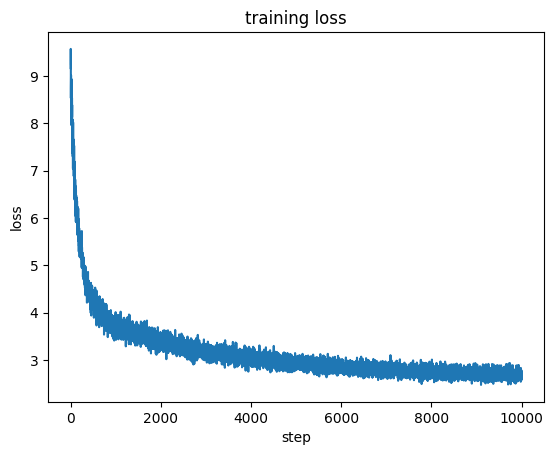

In [35]:
stepi,lossi=train(X,Y,lr=0.01,batch_size=1000)
plt.plot(stepi,lossi)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('training loss')
plt.show()


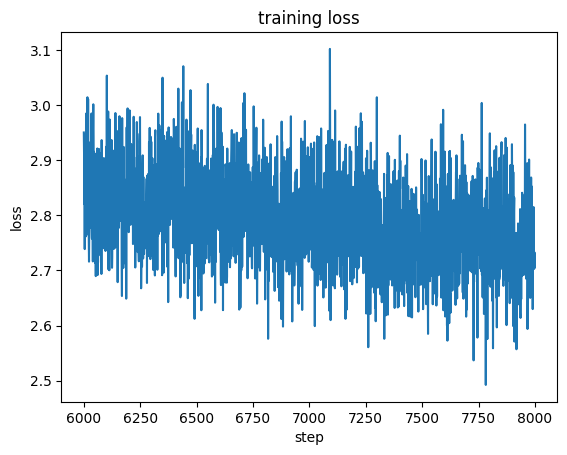

In [36]:
plt.plot(stepi[6000:8000],lossi[6000:8000])
plt.xlabel('step')
plt.ylabel('loss')
plt.title('training loss')
plt.show()

In [39]:
def draw_by_mean(X,Y,start=0,end=len(X),interval_len=100):
    m=int((end-start)/interval_len)
    x=[]
    y=[]
    for i in range(m):
        idx=start+i*interval_len
        xi = sum(X[idx:idx+interval_len]) / interval_len
        yi = sum(Y[idx:idx+interval_len]) / interval_len
        x.append(xi)
        y.append(yi)
    plt.plot(x,y)
    plt.show()

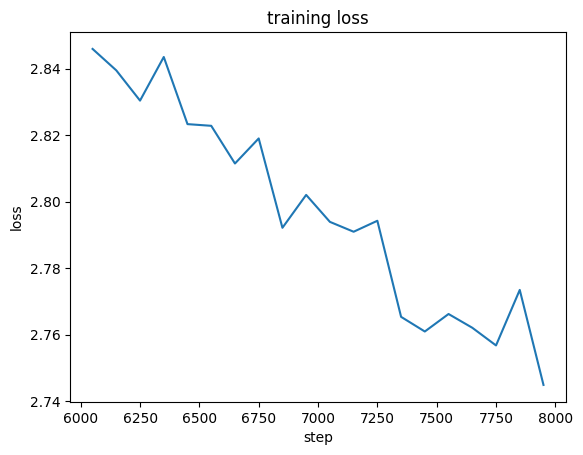

In [37]:
draw_by_mean(stepi,lossi,start=6000,end=8000)

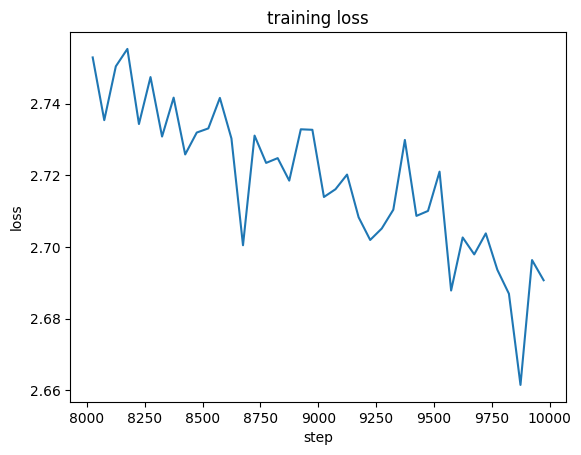

In [38]:
draw_by_mean(stepi,lossi,8000,10000,interval_len=50)

In [15]:
@torch.no_grad()
def predict(max_len=20,output_n=1):
    outs=[]
    for _  in range(output_n):
        
        out=[]
        context=[0]*block_size
        for _ in range(max_len):
            emb=C[context]
            emb_cat=emb.view(-1,block_size*emb_size)
            h=torch.tanh(emb_cat@W1+b1) # 32*200
            logits=h@W2+b2
            probs=F.softmax(logits,dim=1)
            ix=torch.multinomial(probs,num_samples=1).item()
            context=context[1:]+[ix]
            out.append(ix)
            if ix==0:
                break
        outs.append(''.join(itos[ix]for ix in out))
    
    

    
    return outs[0] if len(outs)==1 else outs
        
                

In [16]:
predict(output_n=10)

['aahli.',
 'glerrink.',
 'doyten.',
 'benorelynnian.',
 'airin.',
 'prejy.',
 'bah.',
 'tefsiy.',
 'nyrin.',
 'jaki.']

In [17]:
# -----------------------------------------
# 拆分数据集
random.seed(114514)
random.shuffle(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

Text(0, 0.5, 'loss')

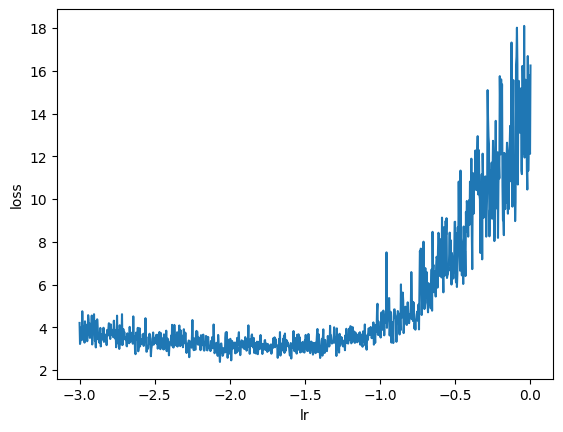

In [ ]:
# 学习率调优
lre=torch.linspace(-3,0,1000)
lrs=10**lre 
lri=[]
lossi=[]

for i  in range(1000):
    # minibatch 
    ix=torch.randint(0,Xtr.shape[0],(32,))
    # forward pass
    emb=C[Xtr[ix]]
    h=torch.tanh(emb.view(-1,emb_size*block_size)@W1+b1)
    logits=h@W2+b2
    loss =F.cross_entropy(logits,Ytr[ix])

    # backward pass
    for p in params:
        p.grad=None
    loss.backward()
    lr=lrs[i]
    for p in params:
        p.data+=-lr*p.grad
    #记录
    lri.append(lre[i]) # 细节放的是lr的指数
    lossi.append(loss.item())
plt.plot(lri,lossi)
plt.xlabel('lr')
plt.ylabel('loss')
    
    

In [21]:
@torch.no_grad()
def split_loss(split):
    x,y={
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split]
    emb=C[X]
    h=torch.tanh(emb.view(-1,block_size*emb_size)@W1+b1)
    logits=h@W2+b2
    loss=F.cross_entropy(logits,Y)
    print(split,loss.item())
split_loss('train')
split_loss('val')

train 17.48665428161621
val 17.48665428161621


In [22]:
def init_params():
    W1=torch.randn((30,200),generator=g)
    b1=torch.randn(200,generator=g)
    #输出层
    W2=torch.randn((200,27),generator=g)
    b2=torch.randn(27,generator=g)
    params=[W1,b1,W2,b2]
    return params
    

Text(0, 0.5, 'loss_after_1000_iters')

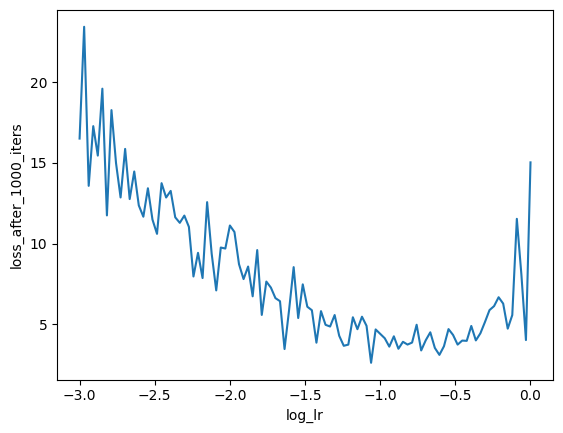

In [ ]:
# 学习率调优


lre=torch.linspace(-3,0,100)
# 待测的lr 和lr对应的训1000轮后的loss
lrs=10**lre 
losses=[] 
vars=[]
for i  in range(100):
    lr=lrs[i]
    params=init_params()
    W1=params[0]
    b1=params[1]
    W2=params[2]
    b2=params[3]
    for p in params:
        p.requires_grad=True
    
    stepi,lossi=train(Xdev,Ydev,lr=lr,iterations=1000)
    losses.append(lossi[-1])

plt.plot(lre,losses)
plt.xlabel('log_lr')
plt.ylabel('loss_after_1000_iters')

draw_by_mean()


In [48]:
import torch.nn as nn
class MLPModel(nn.Module):
    def __init__(self,vocab_size,embedding_dim,block_size,n_hidden):
        super().__init__()
        self.emb=nn.Embedding(block_size,embedding_dim)
        self.fc1=nn.Linear(block_size*embedding_dim,n_hidden)
        self.fc2=nn.Linear(n_hidden,vocab_size)
    def forward(self,x):
        emb=self.emb(x)
        emb=emb.view(x.shape[0],-1)
        h=torch.tanh(self.fc1(emb))
        logits=self.fc2(emb)
        return logits


In [49]:
model=MLPModel(vocab_size=27,embedding_dim=10,block_size=3,n_hidden=200)
for p in model.parameters():
    print(p.shape)

torch.Size([3, 10])
torch.Size([200, 30])
torch.Size([200])
torch.Size([27, 200])
torch.Size([27])


In [ ]:
print(sum(p.numel()for p in model.parameters()))

11657


In [ ]:
optimizer=torch.optim.SGD(model.parameters(),lr=0.1)
for i  in range(200000):
    ix=torch.randint(0,Xtr.shape[0],(32,))
    logits=model(Xtr[ix])
    loss=F.cross_entropy(logits,Ytr[X])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    